<center><h1><u>Assignment:6- Model Selection </center></h1></u>

Hello everyone!! Welcome back to the Assignment 6 of the time series module.

![](https://c.tenor.com/2crKC0rsbcIAAAAM/mr-bean-funny.gif)

In this assignment you will be learning how to select the best model for your time series analysis.

<h2><u>Table of Contents:</h2></u>

1. Model Selection<br>
2. What is AIC<br>
3. What is BIC<br>
4. Implementing Model Selection<br>

<h2><u>Model Selection</h2></u>

Model selection is the process of selecting the best model by trying different hyperparameters and selecting the model that gives best performance. In time series analysis we have used auto arima to do so. But what exactly is a "best" model? You are going to study the criteria for selecting the best model in this assignment. <br><br>
Notice that Machine learning people will approach this problem differently, but time series analysis uses statistical methods, hence model selection in time series is also grounded on statistical methods which are AIC and BIC.

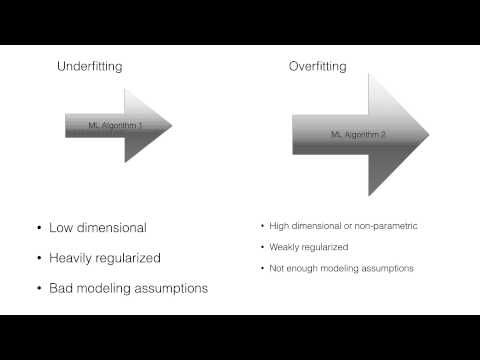

In [ ]:
###Refer Video
from IPython.display import YouTubeVideo
YouTubeVideo('gajUDdlBX3w', width=700, height=400)

<h4><u>The Challenge of Model Selection</h4></u>

The process of fitting numerous models to a dataset and selecting one above the others is known as model selection.

This can be applied to both unsupervised and supervised learning, such as selecting a clustering model for a clustering problem or selecting a predictive model for a regression or classification job.
For model selection, there are a variety of ways that can be employed. In supervised learning, for example, the three most frequent methodologies are

* Train, Validation, and Test datasets.
* Resampling methods
* Probabilistic Statistics

![](https://miro.medium.com/max/1196/1*s2NqGsdIg2lXmiDx-cLlcg.png)

* Fitting candidate models on a training set, tweaking them on the validation dataset, and selecting the best model on the test dataset based on a given metric, such as accuracy or error, is the simplest and most reliable technique of model selection. One issue with this method is that it necessitates a large amount of data.

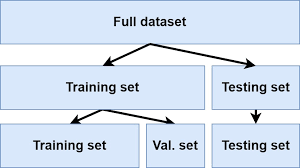

* A good example of resampling methods is k-fold cross-validation, which divides a training set into multiple train/test pairs and fits and evaluates a model on each. This is done for each model, and the model with the best average score across the k-folds is chosen. The difference between this approach and the previous one is that just model performance is evaluated, independent of model complexity.

* A third method of model selection combines the model's complexity and performance into a score, which is then used to select the model that reduces or maximises the score.Because the scoring system uses a probabilistic framework, we might call this approach statistical or probabilistic model selection.

An analytical technique for scoring and choosing among candidate models is probabilistic model selection (or "information criteria").

Models are graded based on their performance on the training dataset as well as the model's complexity.

* **Model performance:** The performance of a candidate model on the training dataset.
* **Model complexity:** After training, how complicated the trained candidate model is.
A probabilistic framework, such as log-likelihood under the paradigm of maximum likelihood estimation, can be used to assess model performance. The number of degrees of freedom or parameters in a model can be used to assess its complexity.

![](https://i0.wp.com/neptune.ai/wp-content/uploads/model-complexity-1.png?resize=383%2C316&ssl=1)

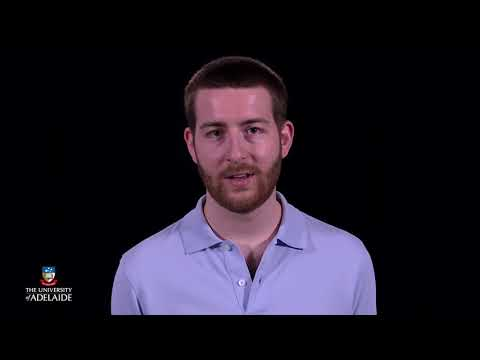

In [ ]:
YouTubeVideo('4al2LfJz6Q8', width=700, height=400)

<h2><u>
Akaike Information Criterion</h2></u>

The Akaike Information Criterion, or AIC for short, is a method for scoring and selecting a model. The model with the lowest AIC is selected.<br><br>
The formula for AIC is:<br>
**AIC = 2k- 2l**<br>
where,<br>
k=number of parameters<br>
l=maximum log likelihood

![](https://timeseriesreasoning.files.wordpress.com/2021/06/a6352-1nurn_wtjfpwin0mc6t7myq.png)

* <u>What is log likelihood?</u>

Maximum likelihood estimate is a method for determining values for model parameters. By maximising the likelihood function, it is a statistical approach for estimating the parameters of a probability distribution.

In Maximum Likelihood Estimation, we wish to maximize the probability of observing the data from the joint probability distribution given a specific probability distribution and its parameters, stated formally as:


### watch the below given videos to know about log likelihood


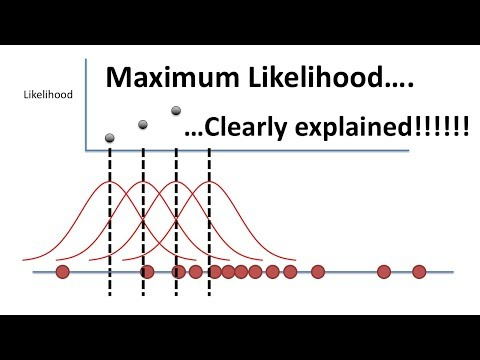

In [ ]:
YouTubeVideo('XepXtl9YKwc', width=700, height=400)

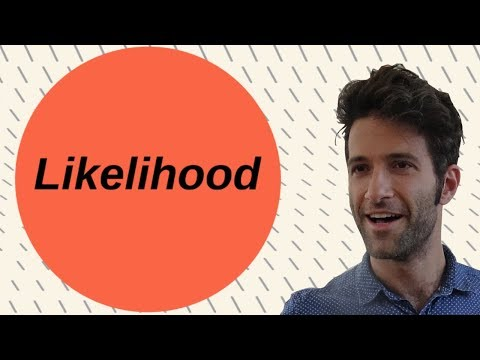

In [ ]:
YouTubeVideo('ScduwntrMzc', width=700, height=400)

<h2><u>Bayesian Information Criterion</h2></u>

The formula for BIC is:<br>
**BIC=ln(n)k-2l**
where,<br>
k=number of parameters<br>
l=maximum log likelihood<br>
n=number of samples used for fitting

The model with the lowest BIC is selected.

![](https://miro.medium.com/max/294/1*oRNdu-do4lM_f2putrDKog.png)

Although the quantity determined differs from the AIC, it may be proven to be proportional to it. Unlike the AIC, the BIC penalises models for their complexity, which means that more complex models will have a lower (bigger) score and, as a result, will be less likely to be chosen.

<h2><u>Implementing Model Selection</h2></u>

We will see how AIC and BIC are used to select the best models. For that we will use ARIMA models with different orders.


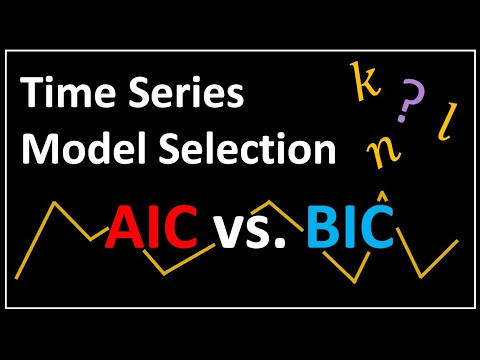

In [ ]:
YouTubeVideo('McEN54l3EPU', width=700, height=400)

Lets begin by importing the necessary libraries.

* pandas: for storing and analyzing data
* datetime: for manipulating dates and times.,https://docs.python.org/3/library/datetime.html
* numpy: for array and matrix operations
* matplotlib: for plotting graphs
* plot_acf,plot_pacf: to plot ACF and PACF
* ARIMA: to implement ARIMA model
* adfuller: to implement adf test

In [3]:
#import above mentioned libraries
# Importing the necessary libraries

# For storing and analyzing data
import pandas as pd

# For manipulating dates and times
from datetime import datetime

# For numerical operations, arrays, and matrices
import numpy as np

# For plotting graphs
import matplotlib.pyplot as plt


# For plotting ACF and PACF graphs
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# For implementing the ARIMA model
from statsmodels.tsa.arima.model import ARIMA

# For performing the Augmented Dickey-Fuller (ADF) test
from statsmodels.tsa.stattools import adfuller

Next import the warnings library and filter the warnings as 'ignore'

In [2]:
#import warnings
# Import warnings library
import warnings

# Ignore all warnings
warnings.filterwarnings("ignore")
#filter warnings


Now define a parser function that will parse the dates into '%Y-%m-%d' format. Use the datetime.strptime method to do so.

In [4]:
#define parser method
from datetime import datetime

# Parser function
def parser(date):
    return datetime.strptime(date, '%Y-%m-%d')


Define a function perform_adf_test that will apply the adf test for finding stationarity in the data.

In [5]:
from statsmodels.tsa.stattools import adfuller

# Function to perform ADF Test
def perform_adf_test(data):

    result = adfuller(data)

    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

    if result[1] <= 0.05:
        print("Data is Stationary")
    else:
        print("Data is Non-Stationary")

The dataset used in the project is present in the google drive. So the drive has to be first mounted to use the dataset. For that use the drive library from google.colab and then mount the drive using mount function.

In [ ]:
# import drive from google.colab

# mount the drive


Mounted at /content/drive


Start by reading and loading the data. Download the dataset from the given link and upload it in your drive. https://drive.google.com/file/d/1l3Y0K22BABGnVhcXS7v47SZATHODNavp/view?usp=sharing

After uploading use your dataset link for reading the data in the read_csv method. The dataset has two columns date and values. parse_dates attribute is to parse the dates so that it can be represented as an array of datetimes. parse_dates is used to make the dates uniform as dates can be present in different formats. Refer documentation: https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html. index_cols attribute is set to 0 which specifies Column(s) to use as the row labels of the DataFrame, either given as string name or column index. Squeeze attribute returns a Series if parsed data only contains one column. date_parser takes the parser function we defined earlier to parse the dates. Next the series is applied the asfreq function which Convert time series to specified frequency.https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.asfreq.html

In [7]:
# Read and load the dataset

series = pd.read_csv(
    '/content/drug sales.csv',
    parse_dates=[0],
    index_col=0,
    date_parser=parser
).squeeze("columns")

# Convert series to daily frequency
series = series.asfreq('D')

# Display first 5 rows
print(series.head())

date
1991-07-01    3.526591
1991-07-02         NaN
1991-07-03         NaN
1991-07-04         NaN
1991-07-05         NaN
Freq: D, Name: value, dtype: float64


In [10]:
from statsmodels.tsa.stattools import adfuller

# Function to perform ADF Test
def perform_adf_test(data):

    result = adfuller(data)

    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

    if result[1] <= 0.05:
        print("Data is Stationary")
    else:
        print("Data is Non-Stationary")


# Remove missing values
series = series.dropna()

# Perform ADF Test
perform_adf_test(series)

ADF Statistic: 3.14518568930673
p-value: 1.0
Data is Non-Stationary


Lets perform the augmented dickey fuller test by applying the perform_adf_test function created before. This will check whether the data is stationary or not.

The p values is 1.000 which is more than 0.05(significance level) this means that the data is not stationary. Hence lets differentiate the data once and check the p value. use the diff() function to do so and use the dropna() function to remove null values.

In [11]:
# Differentiate the series and drop NaN values

series_diff = series.diff().dropna()

# Perform ADF Test again
perform_adf_test(series_diff)

ADF Statistic: -2.4951721474497393
p-value: 0.11665341686468789
Data is Non-Stationary


Now lets again check the stationarity using adf test.

In [ ]:
#check stationarity


ADF Statistic: -2.495172
p-value: 0.116653


The value is 0.1166 which is still more than 0.05. Hence you have to differentiate the data once more.

In [13]:
#differentiate for second time
series_diff = series_diff.diff().dropna()
perform_adf_test(series_diff)

ADF Statistic: -10.29230470651732
p-value: 3.543916358529341e-18
Data is Stationary


Again check the p value.

In [ ]:
#check stationarity


ADF Statistic: -10.292305
p-value: 0.000000


Hurray!! the p value is 0.00 which is less than 0.05. hence the data is now stationary. The next step is to find the p,q values. For that we need to plot the pacf for finding p values and acf for finding q values.

<Figure size 1000x500 with 0 Axes>

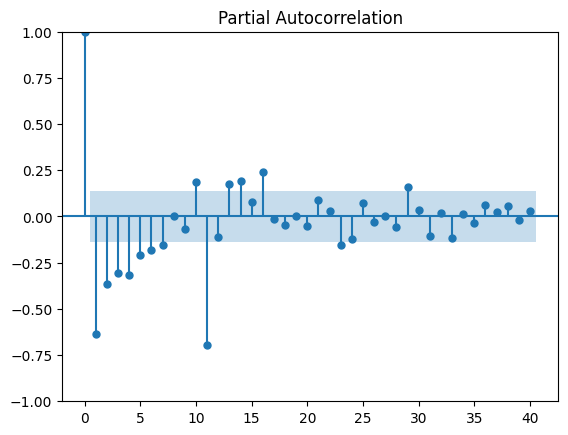

In [14]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf

# Plot PACF graph
plt.figure(figsize=(10,5))

plot_pacf(series_diff, lags=40)

plt.show()

Hence the values of lags 1,2,3,4,5,6,7,10 are above significance level. Hence these values shall be considered for p values(order of AR).<br> Next plot the acf.

<Figure size 1000x500 with 0 Axes>

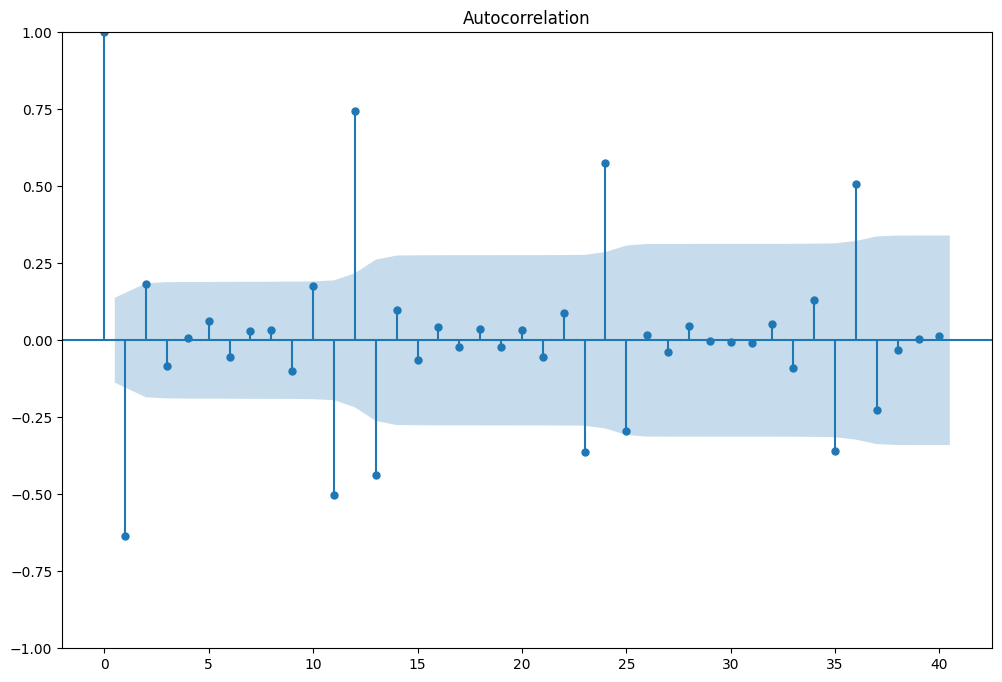

Training ARIMA (1, 2, 1)
AIC: 1175.7512067591115
BIC: 1185.6461588587556


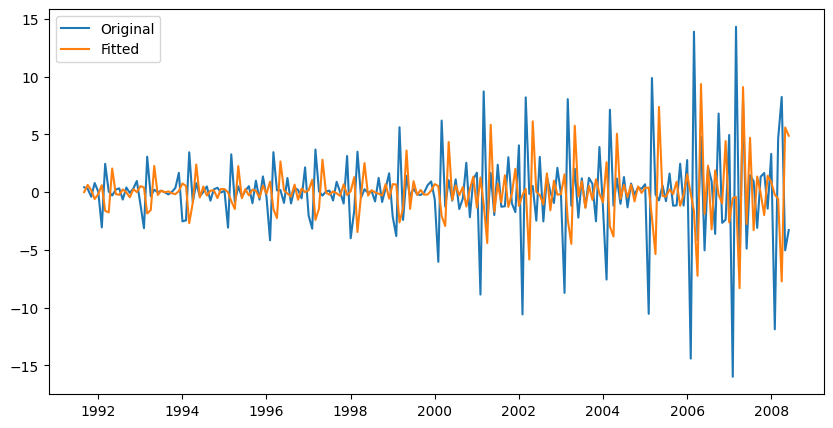

Training ARIMA (1, 2, 2)
AIC: 1014.988371727828
BIC: 1028.1816411940201


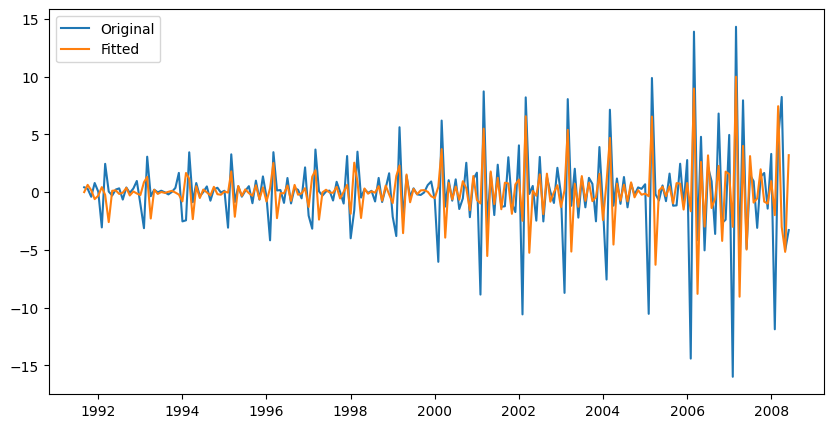

Training ARIMA (2, 2, 1)
AIC: 1113.0380753413983
BIC: 1126.2313448075904


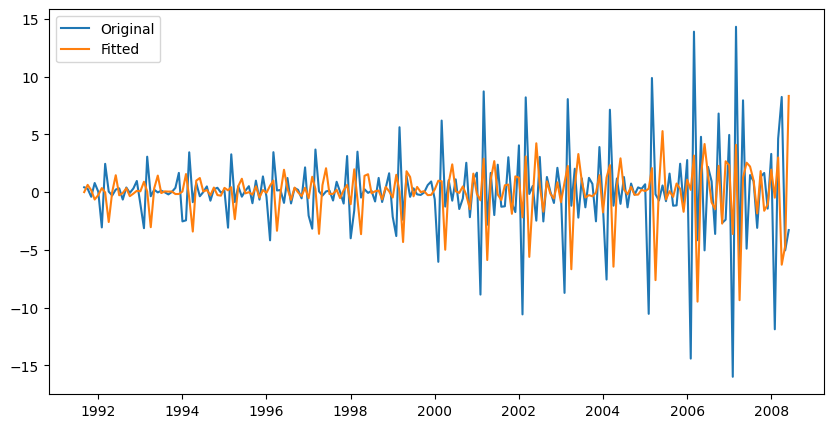

Training ARIMA (2, 2, 2)
AIC: 986.9393990502409
BIC: 1003.4309858829811


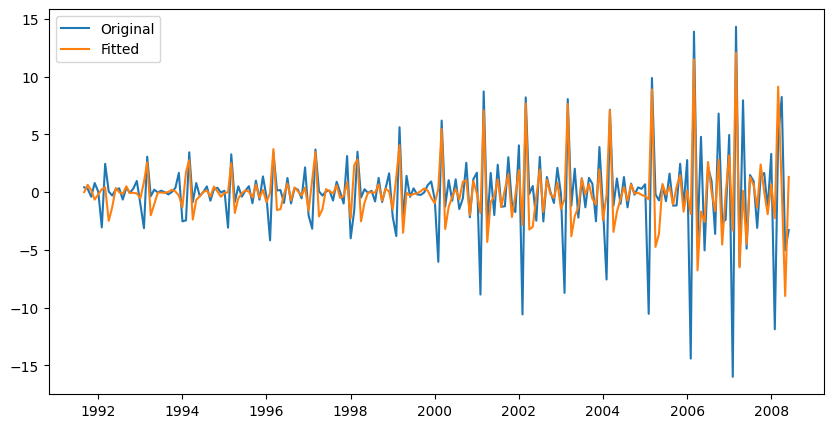

Training ARIMA (3, 2, 1)
AIC: 1078.7576850420237
BIC: 1095.249271874764


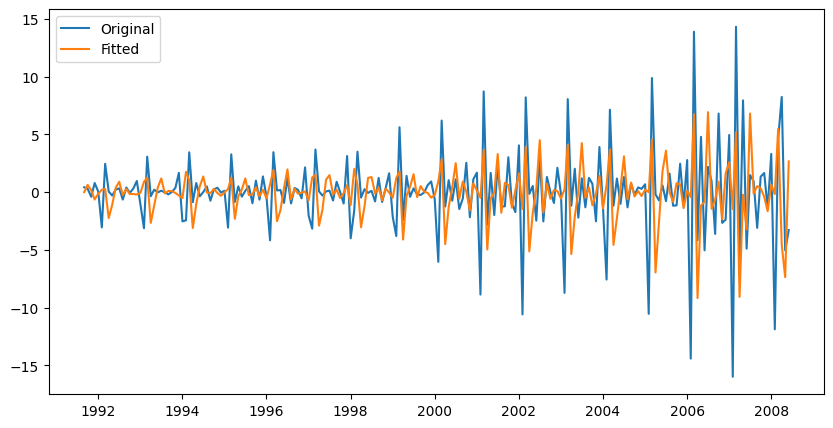

Training ARIMA (3, 2, 2)
AIC: 1093.3021521017363
BIC: 1113.0920563010245


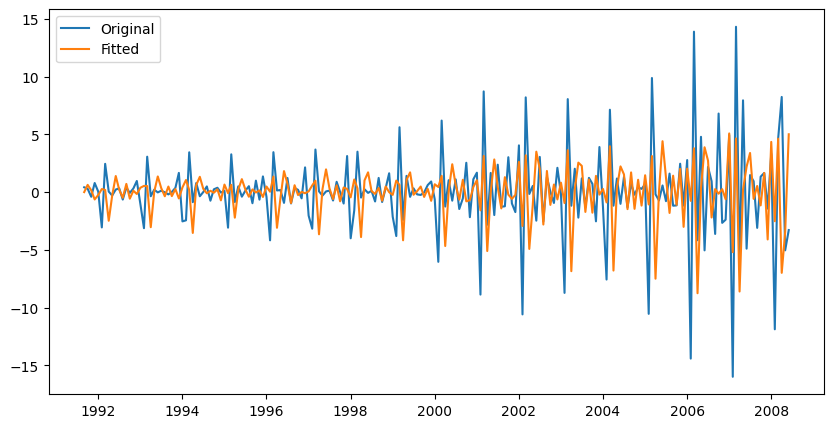

Training ARIMA (4, 2, 1)
AIC: 1045.66079584393
BIC: 1065.4507000432181


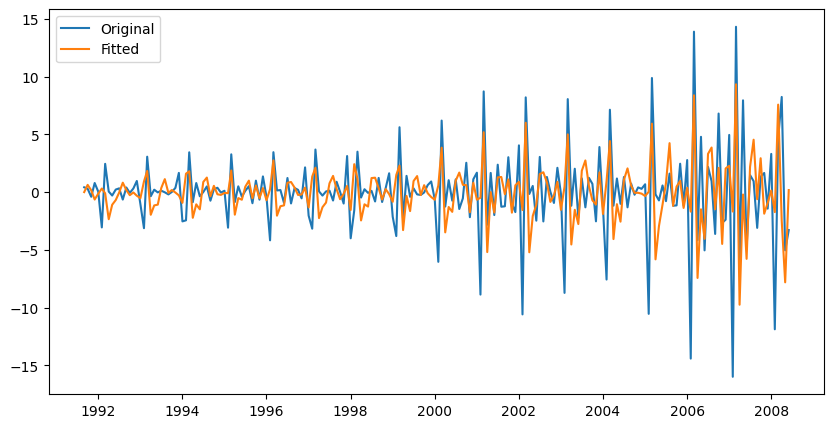

Training ARIMA (4, 2, 2)
AIC: 952.0837632153737
BIC: 975.17198478121


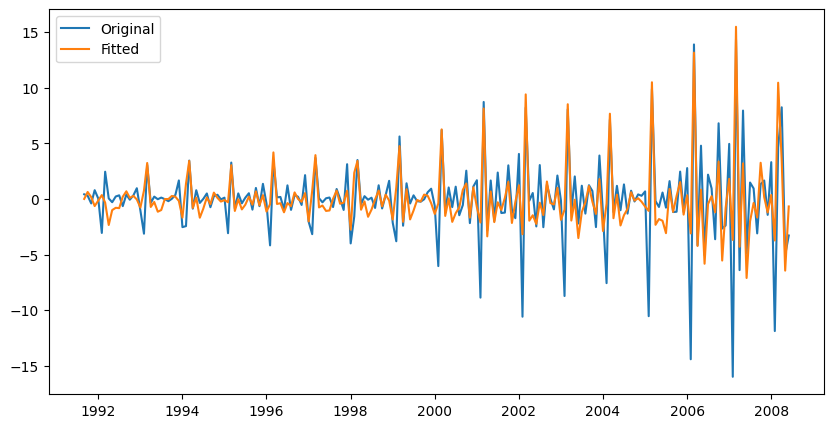

Training ARIMA (5, 2, 1)
AIC: 1025.106460590408
BIC: 1048.1946821562442


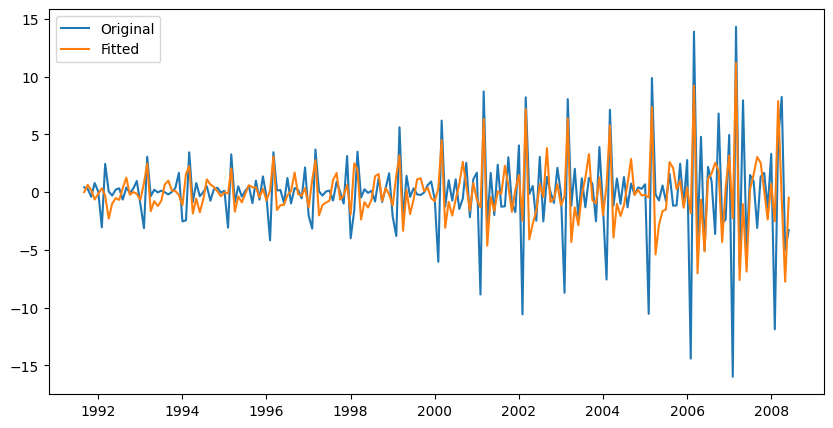

Training ARIMA (5, 2, 2)
AIC: 1018.6946502556643
BIC: 1045.0811891880487


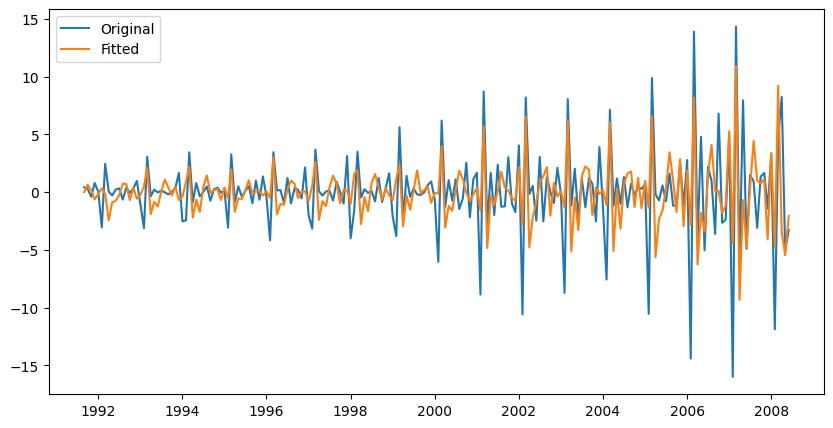

Training ARIMA (6, 2, 1)
AIC: 1010.8391158293688
BIC: 1037.225654761753


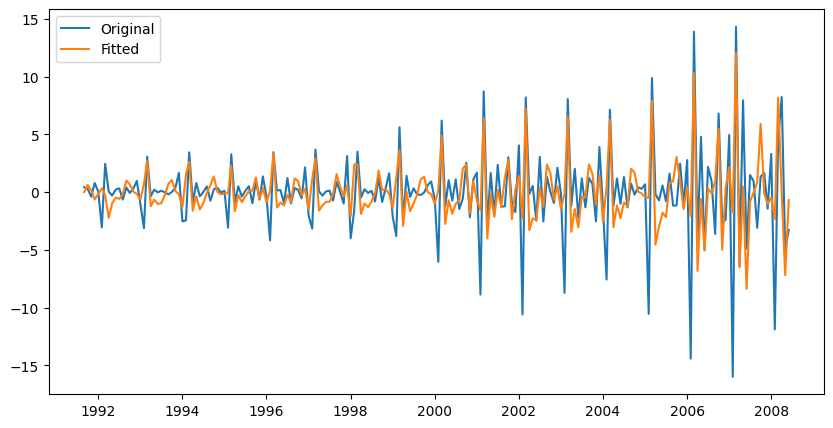

Training ARIMA (6, 2, 2)
AIC: 940.8537525725719
BIC: 970.5386088715043


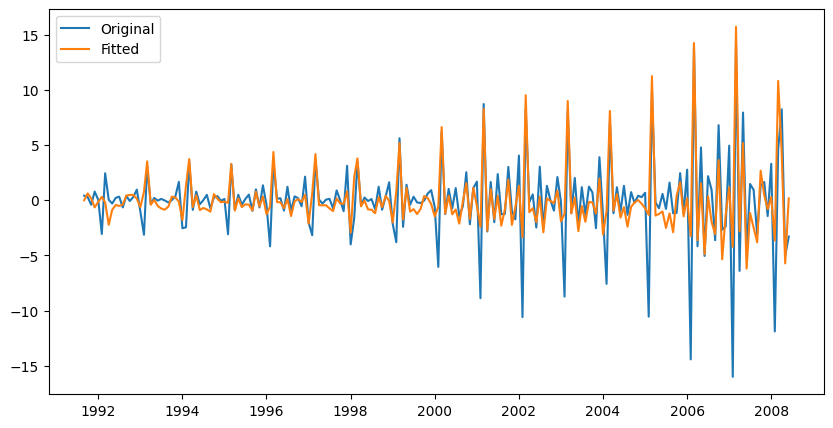

Training ARIMA (7, 2, 1)
AIC: 988.1044600380354
BIC: 1017.7893163369678


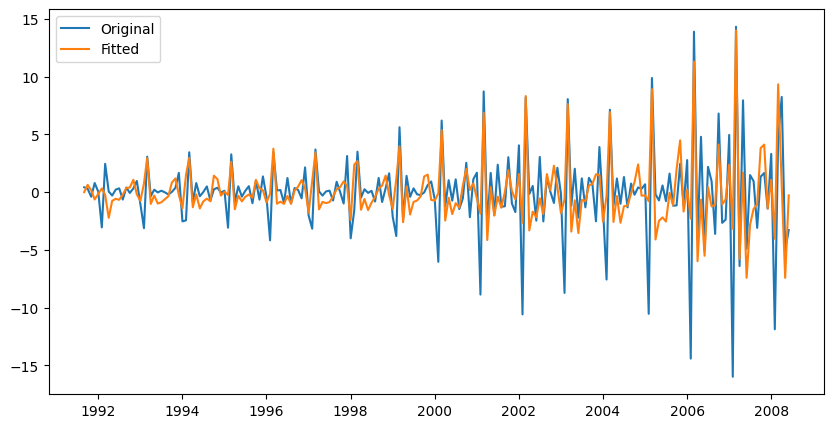

Training ARIMA (7, 2, 2)
AIC: 970.4531604186567
BIC: 1003.4363340841371


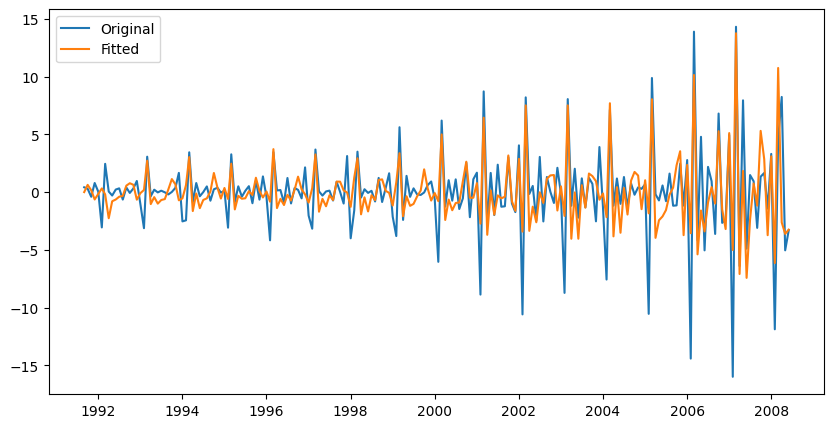

Training ARIMA (10, 2, 1)
AIC: 897.0265440681887
BIC: 936.6063524667652


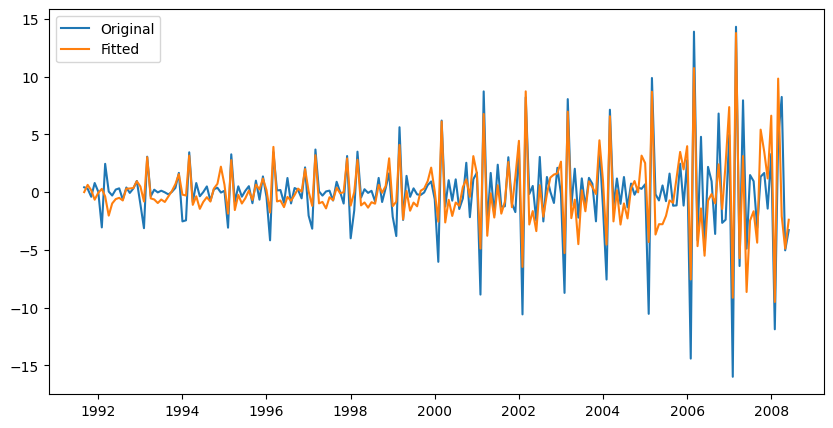

Training ARIMA (10, 2, 2)
AIC: 888.7204062186375
BIC: 931.598531983762


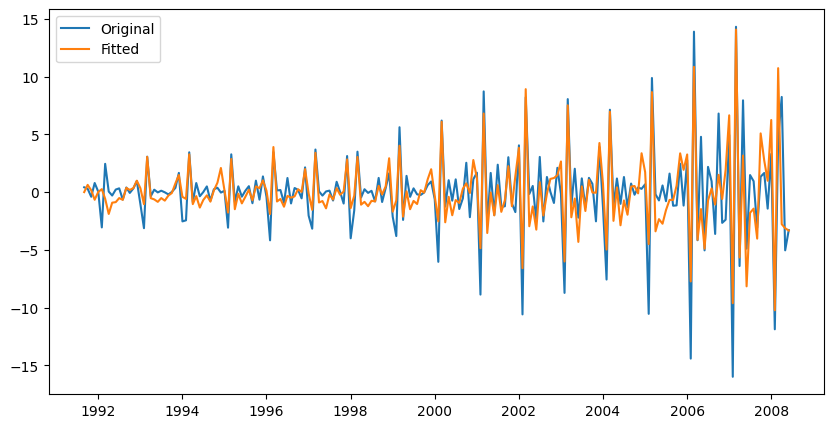

In [19]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA

# Plot ACF
plt.figure(figsize=(10,5))
plot_acf(series_diff, lags=40)
plt.show()

# p and q values
p_values = [1,2,3,4,5,6,7,10]
q_values = [1,2]

# Store combinations
orders = []

for p in p_values:
    for q in q_values:
        orders.append((p,2,q))

# Dictionary to store models
models = {}

# Fit models
for order in orders:

    print("Training ARIMA", order)

    model = ARIMA(series_diff, order=order)

    fitted_model = model.fit()

    models[order] = fitted_model

    print("AIC:", fitted_model.aic)
    print("BIC:", fitted_model.bic)

    # Plot
    plt.figure(figsize=(10,5))

    plt.plot(series_diff, label='Original')

    plt.plot(fitted_model.fittedvalues, label='Fitted')

    plt.legend()

    plt.show()

Hence the values of lags 1,2 are above significance level. Hence these values shall be considered for q values(order of MA). <br><br>
Next step is the major step to fit the ARIMA models. We will have total 16 values by combining various values of p and q. For that create a list having tuples of p and q combinations. Iterate through these tuple values and create the arima model for that values. Append the fitted model into a dictionary. Refer:https://www.w3schools.com/python/python_dictionaries.asp. And plot the original series as well as the fitted values. ALso print the AIC and BIC scores using the aic and bic methods.

* #### p values(orders of AR):1,2,3,4,5,6,7,10
* #### q values(orders of MA):1,2
* #### d value: 2 (the data was differentiated 2 times)

Training ARIMA (1, 2, 1)


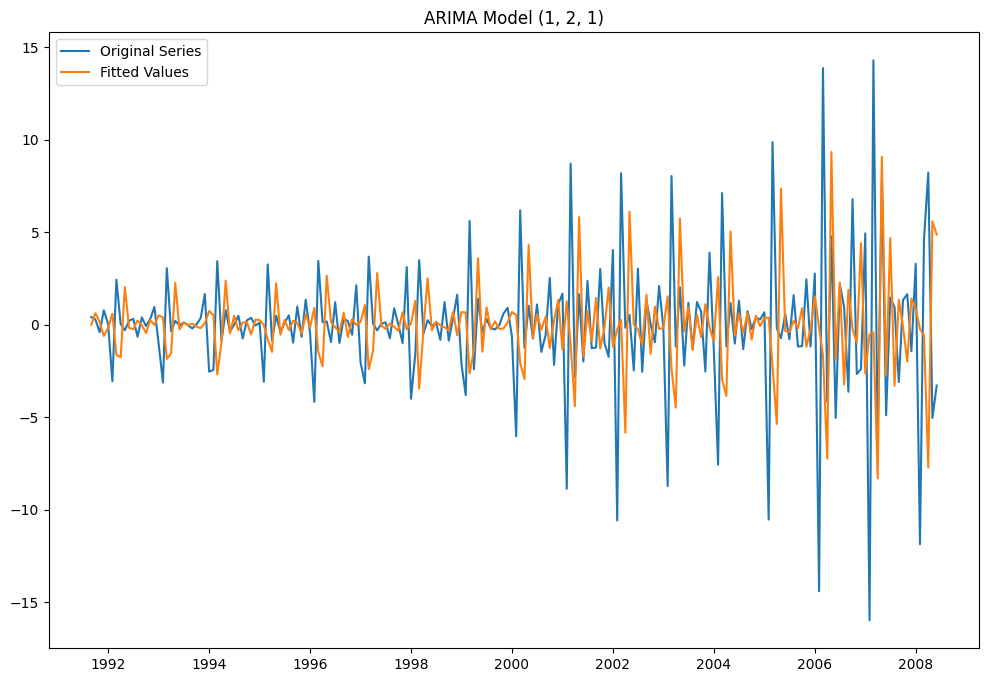

AIC: 1175.7512067591115
BIC: 1185.6461588587556
Training ARIMA (1, 2, 2)


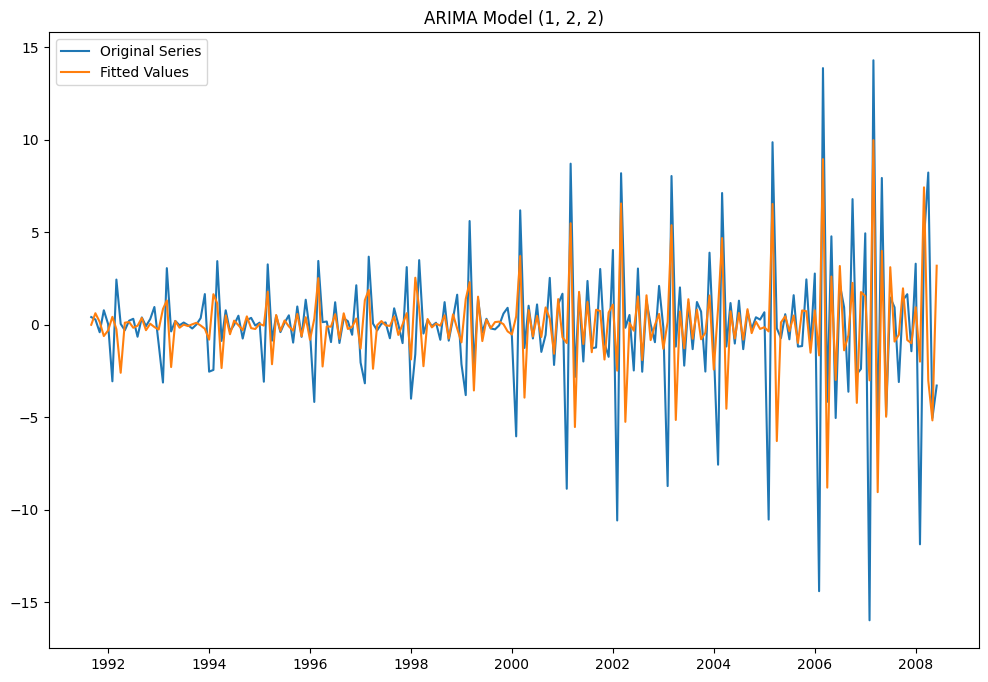

AIC: 1014.988371727828
BIC: 1028.1816411940201
Training ARIMA (2, 2, 1)


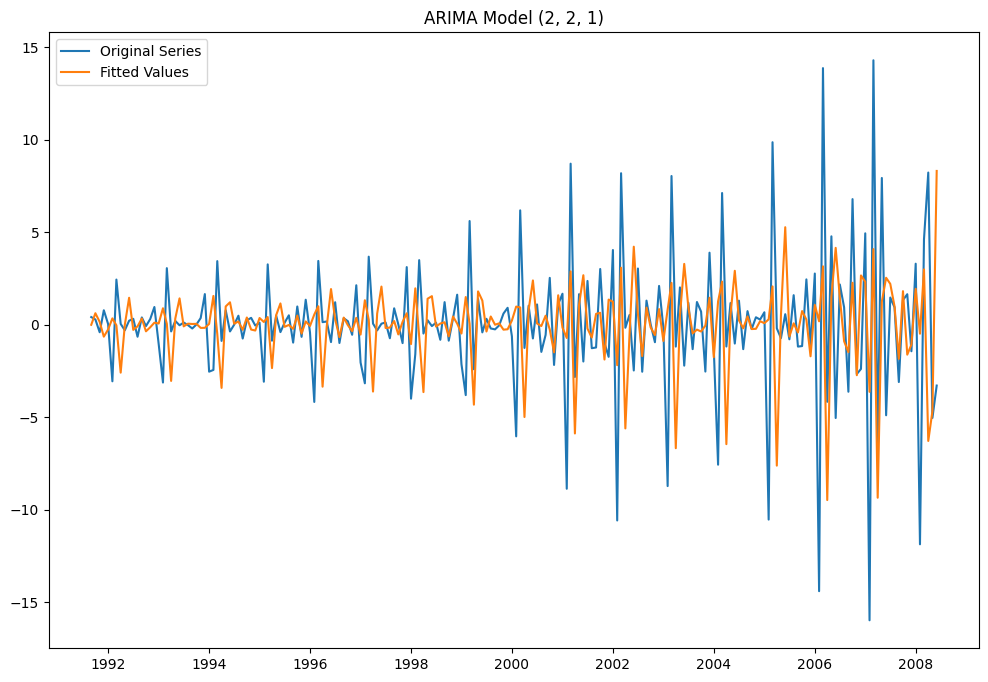

AIC: 1113.0380753413983
BIC: 1126.2313448075904
Training ARIMA (2, 2, 2)


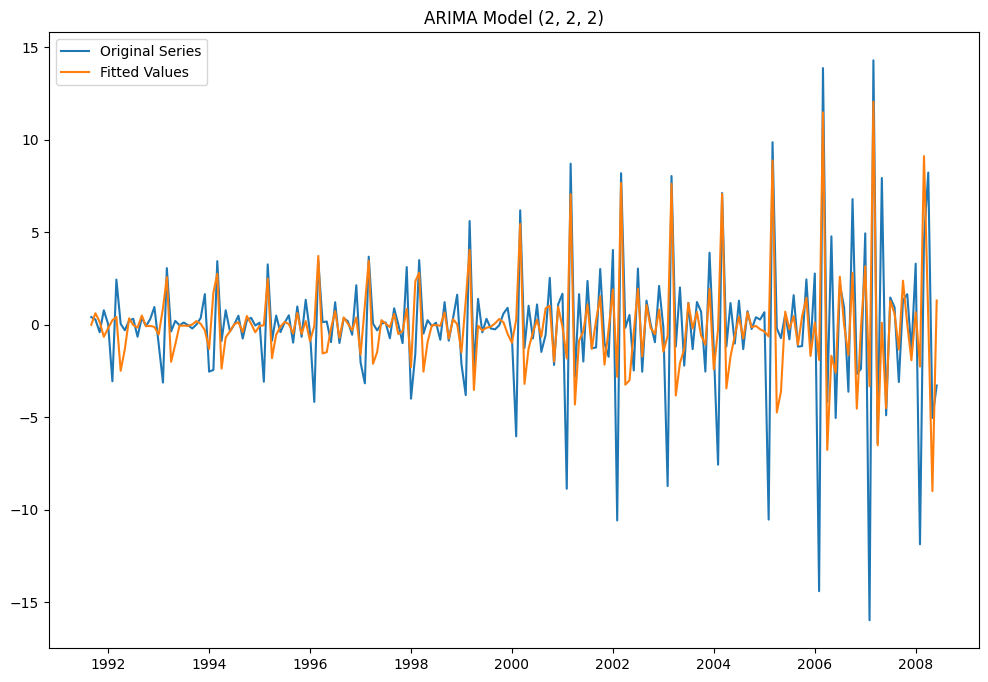

AIC: 986.9393990502409
BIC: 1003.4309858829811
Training ARIMA (3, 2, 1)


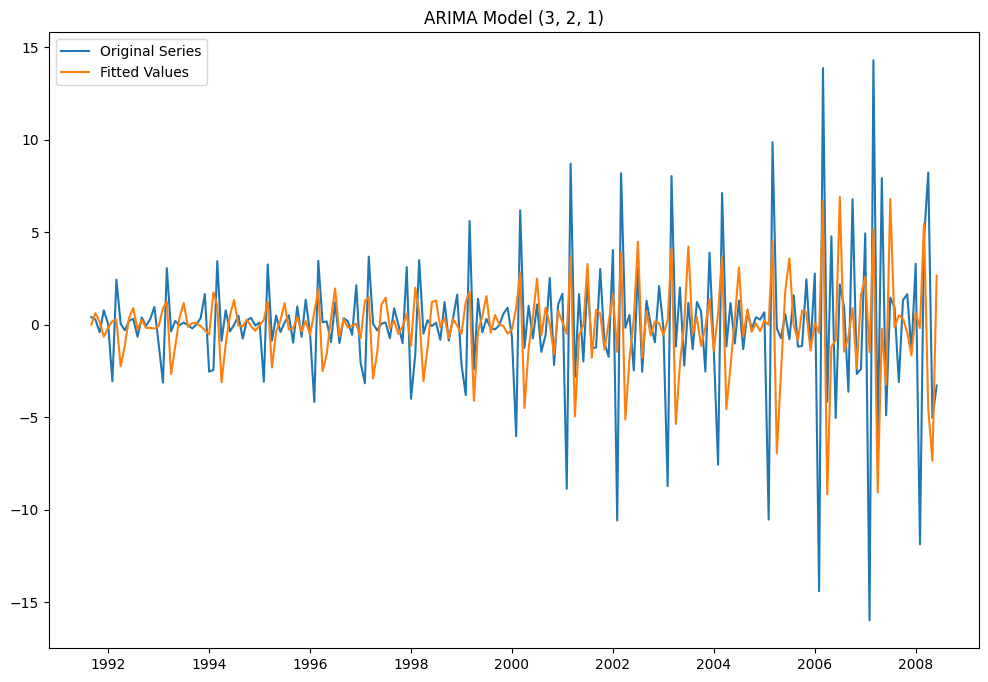

AIC: 1078.7576850420237
BIC: 1095.249271874764
Training ARIMA (3, 2, 2)


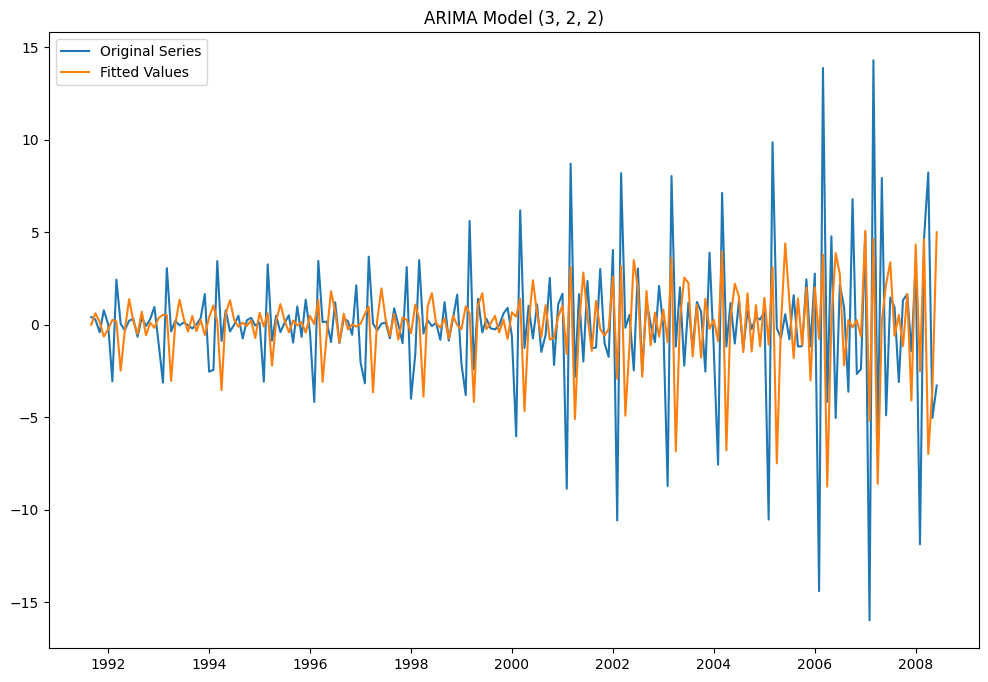

AIC: 1093.3021521017363
BIC: 1113.0920563010245
Training ARIMA (4, 2, 1)


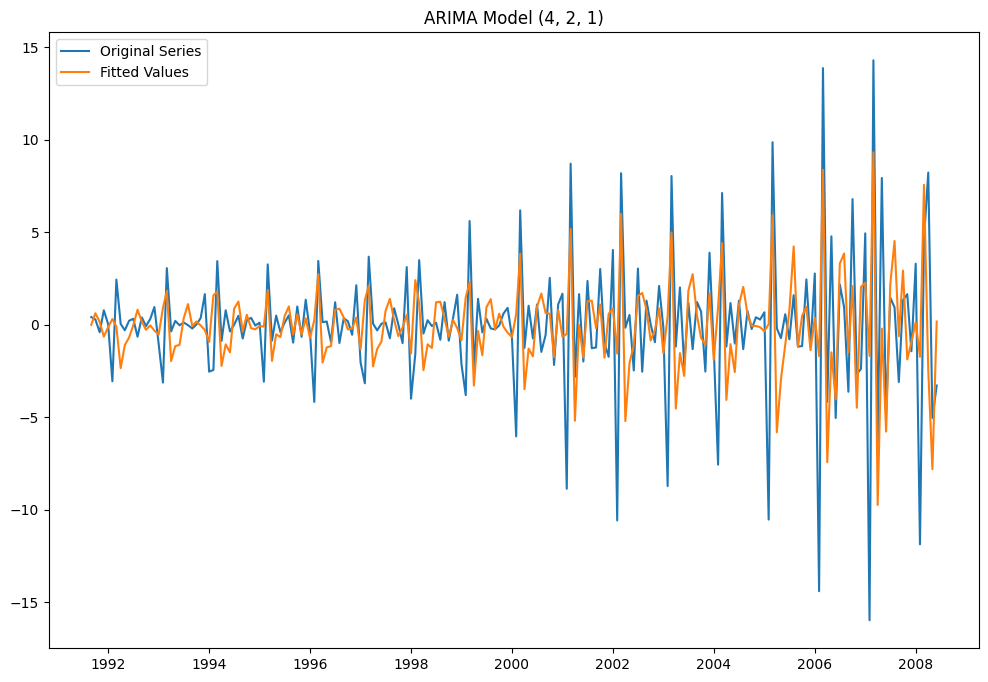

AIC: 1045.66079584393
BIC: 1065.4507000432181
Training ARIMA (4, 2, 2)


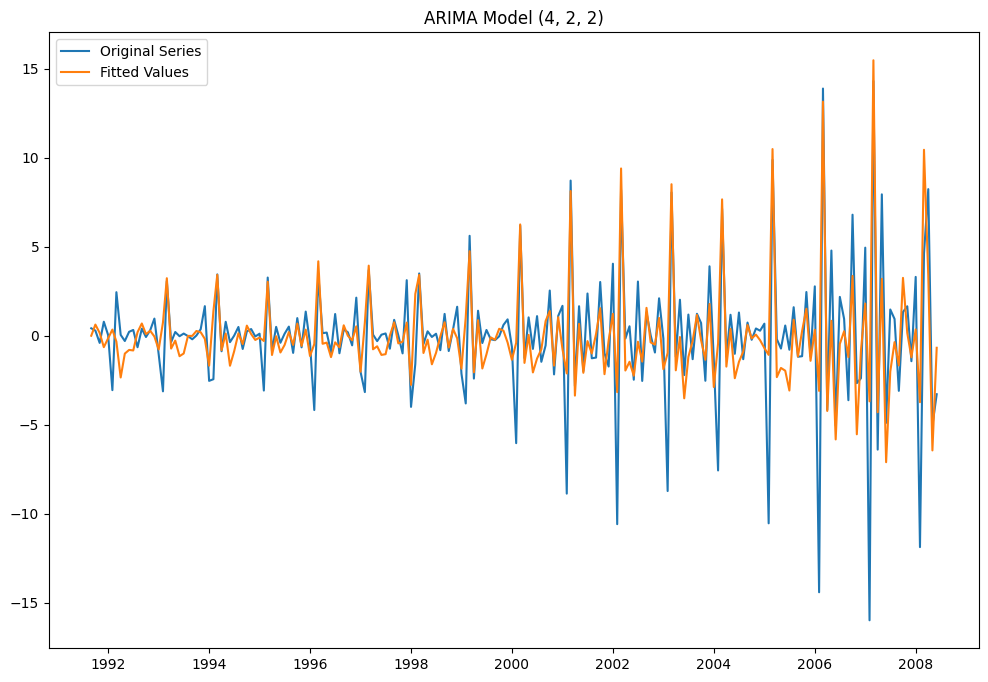

AIC: 952.0837632153737
BIC: 975.17198478121
Training ARIMA (5, 2, 1)


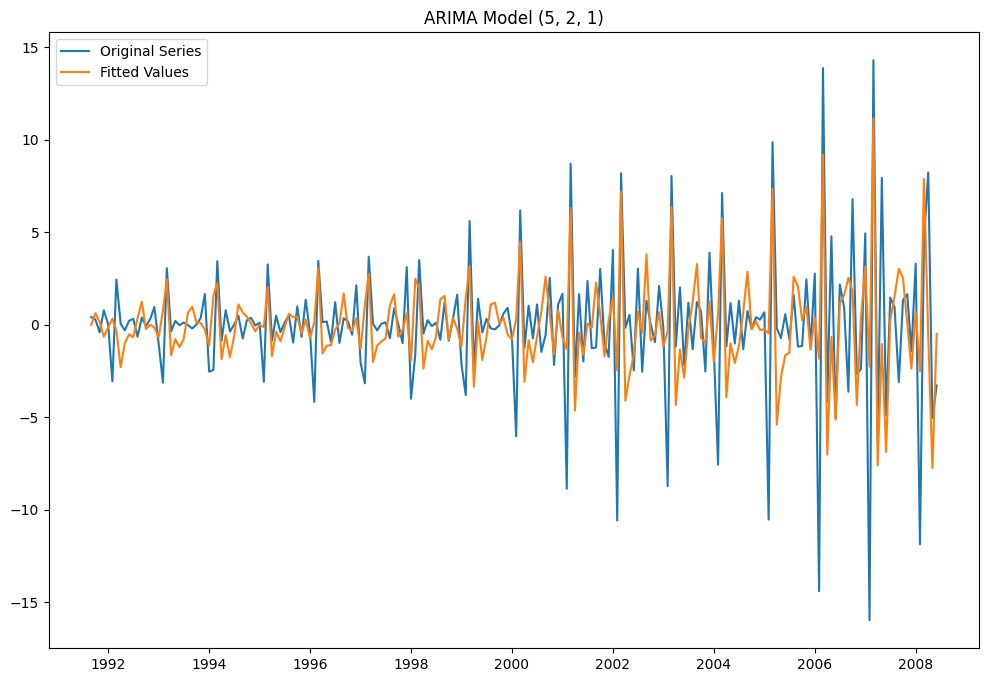

AIC: 1025.106460590408
BIC: 1048.1946821562442
Training ARIMA (5, 2, 2)


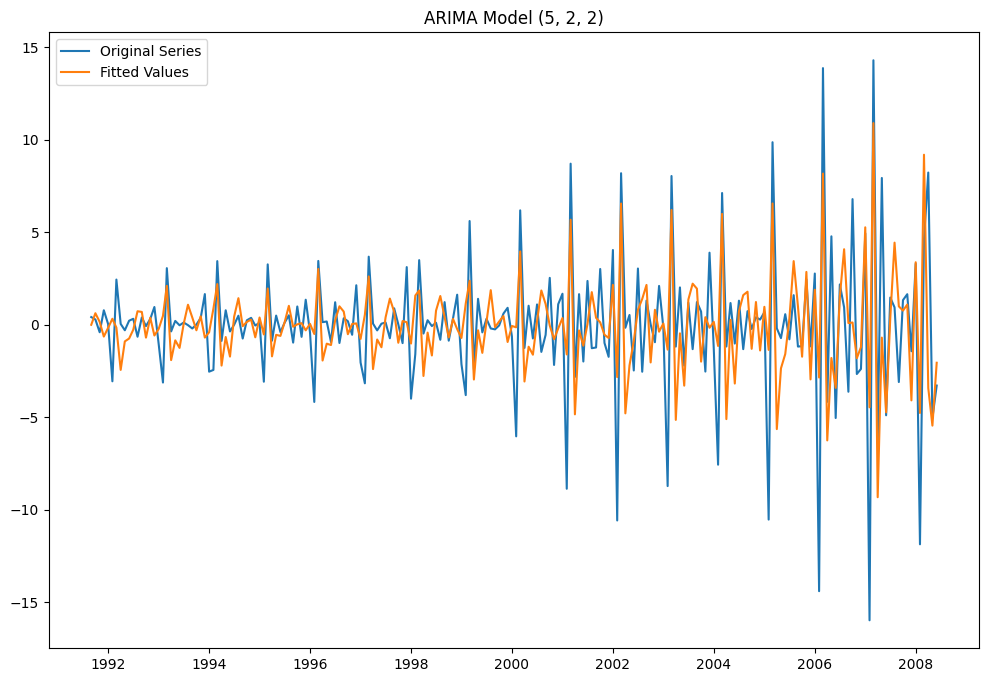

AIC: 1018.6946502556643
BIC: 1045.0811891880487
Training ARIMA (6, 2, 1)


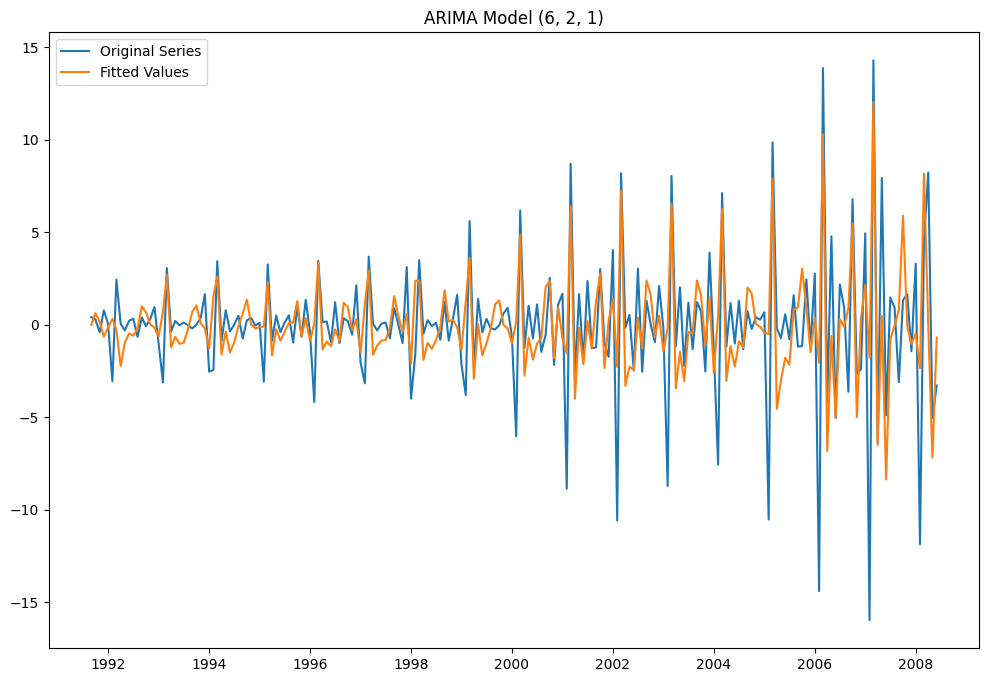

AIC: 1010.8391158293688
BIC: 1037.225654761753
Training ARIMA (6, 2, 2)


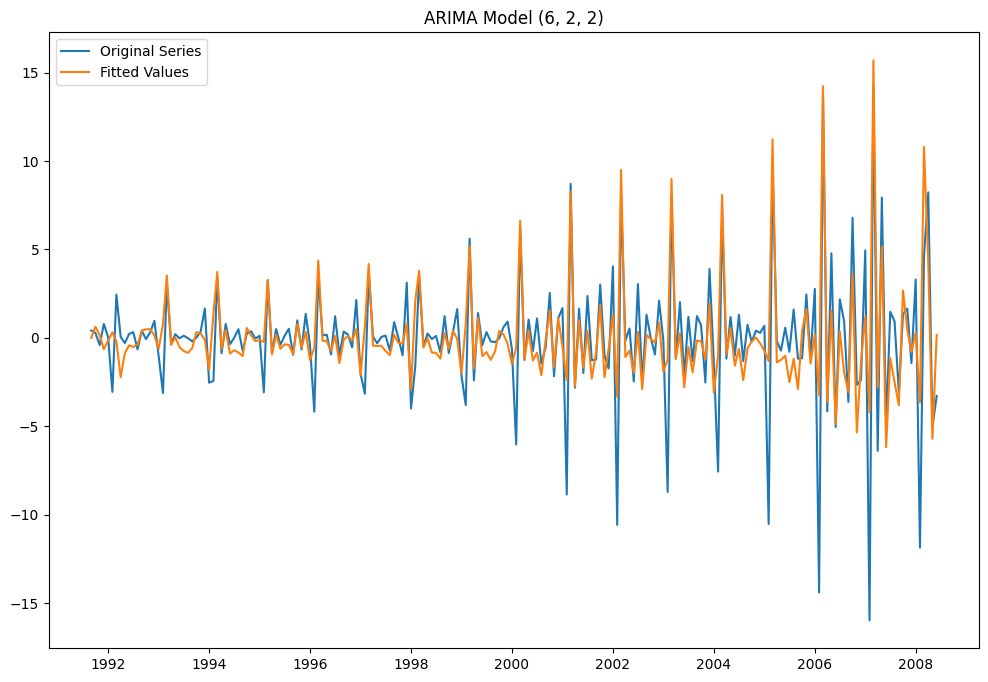

AIC: 940.8537525725719
BIC: 970.5386088715043
Training ARIMA (7, 2, 1)


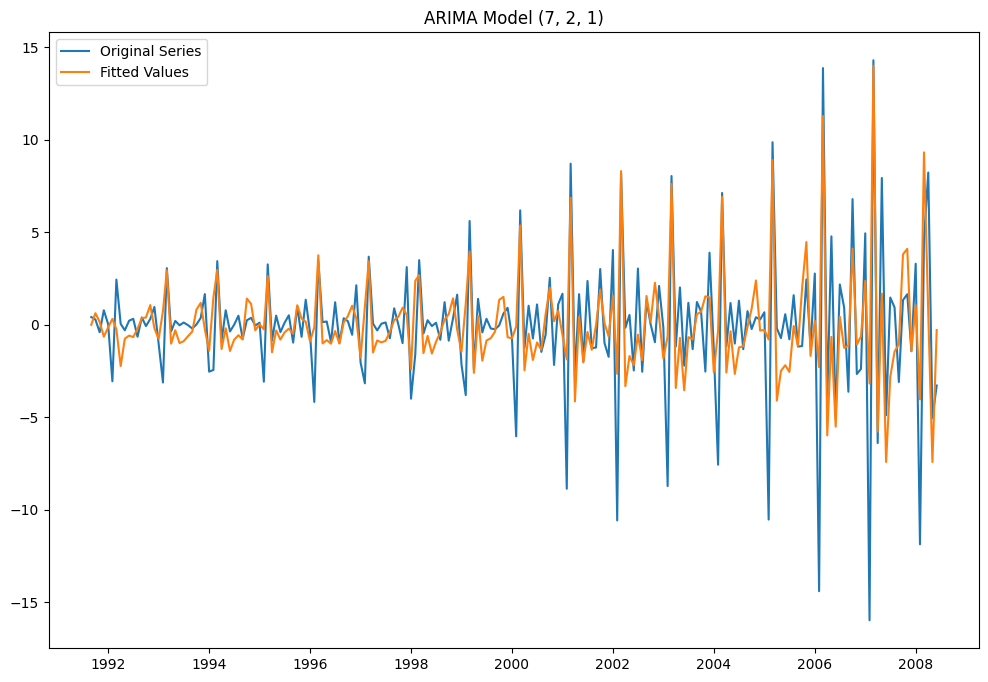

AIC: 988.1044600380354
BIC: 1017.7893163369678
Training ARIMA (7, 2, 2)


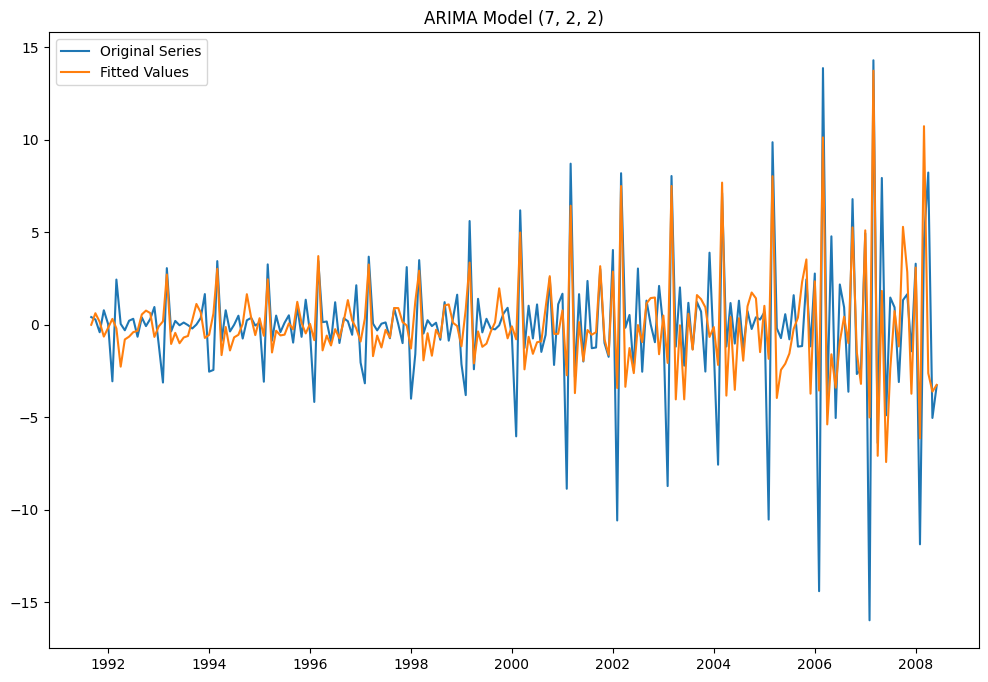

AIC: 970.4531604186567
BIC: 1003.4363340841371
Training ARIMA (10, 2, 1)


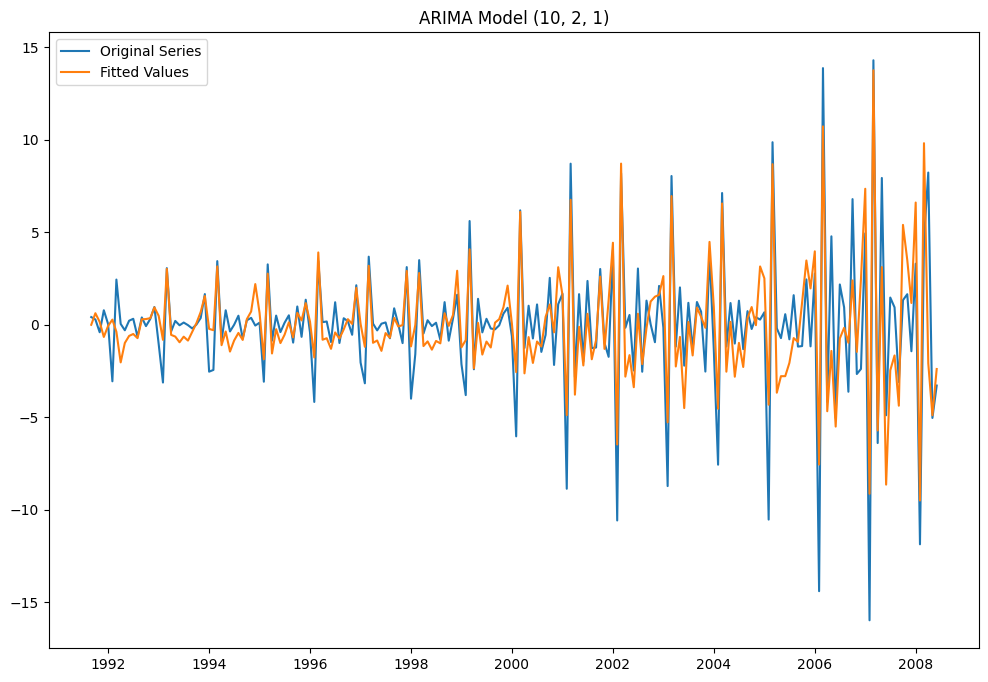

AIC: 897.0265440681887
BIC: 936.6063524667652
Training ARIMA (10, 2, 2)


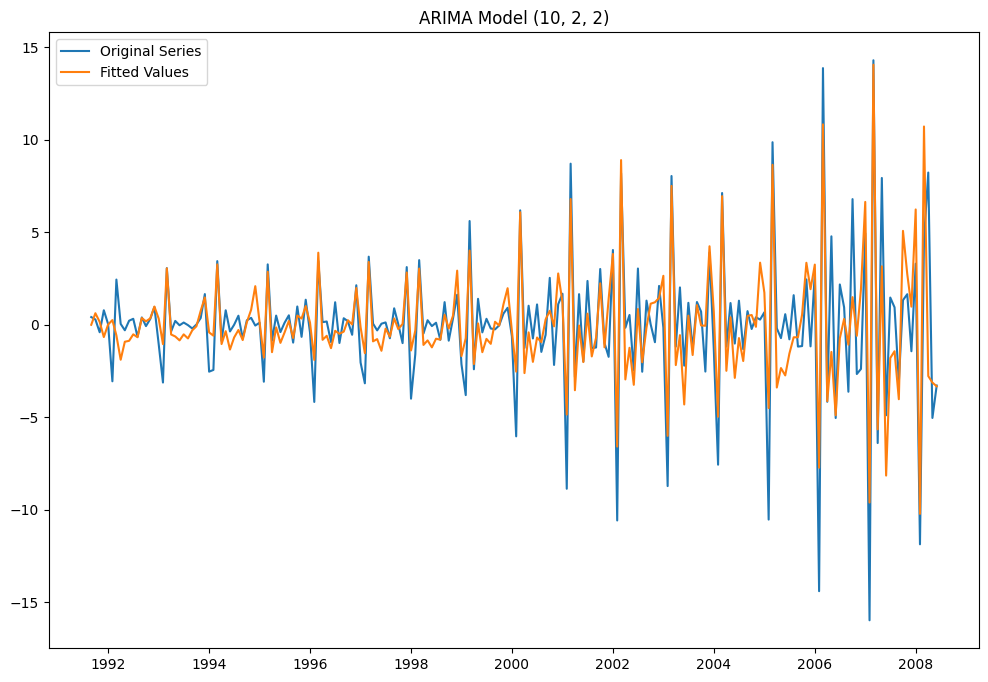

AIC: 888.7204062186375
BIC: 931.598531983762


In [21]:
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# set figure size
plt.rcParams['figure.figsize'] = (12, 8)

# p values
p_values = [1, 2, 3, 4, 5, 6, 7, 10]

# q values
q_values = [1, 2]

# create order list
orders = []

for p in p_values:
    for q in q_values:

        orders.append((p, 2, q))

# dictionary
fitted_model_dict = {}

# loop through orders
for values in orders:

    try:

        print("Training ARIMA", values)

        # create model
        ar_model = ARIMA(series_diff, order=values)

        # fit model
        ar_model_fit = ar_model.fit()

        # store model
        fitted_model_dict[values] = ar_model_fit

        # plot
        plt.figure()

        plt.plot(series_diff, label='Original Series')

        plt.plot(ar_model_fit.fittedvalues,
                 label='Fitted Values')

        plt.title(f'ARIMA Model {values}')

        plt.legend()

        plt.show()

        # print scores
        print("AIC:", ar_model_fit.aic)

        print("BIC:", ar_model_fit.bic)

    except Exception as e:

        print("Error:", e)

By looking at the AIC and BIC of the models,the lowest AIC and BIC scores are for model AR(10),MA(1)
* AIC for AR(10),MA(1): 910.7040137079978
* BIC for AR(10),MA(1): 953.5821394731222

hence we choose this model as the best model.

In this assignment you learned:

* AIC and BIC
* Implementing AIC and BIC


Keep practising until next assignment comes in. <br><br>

## Do fill the feedback form given below:
[Feedback form](https://forms.zohopublic.in/cloudyml/form/CloudyMLDeepLearningFeedbackForm/formperma/VCFbldnXAnbcgAIl0lWv2blgHdSldheO4RfktMdgK7)
<br><br> See you then!!

![](https://i.pinimg.com/originals/e9/26/78/e9267898700539b0ed1fcf55bf195dfe.gif)